# Implementing a 2D analytical steady-state solution to the Richards equation.
We want to test the finite element method with Picard iterations against an analytical solution. Here, the Richards equation is given as <br>
$\frac{\partial \theta}{\partial t} - \nabla\cdot(k\nabla(z+h))$ which means that the hydraulic pressure head is negative above the saturation zone. <br>
In order to get to an analytical solution, the parametrizations are simplified to: <br>
$k=k_sk_r$ with $k_r = e^{\alpha h}$ (Gardner), $k_r = (\frac{\theta - \theta_r}{\theta_s - \theta_r})^m$ (Irmay) where $\alpha, m$ are parameters. For even further simplification we choose $m=1$ here. <br>
We choose $\Omega = [0, 15.24]\times[0, 15.24]$, $\alpha=0.19$ and $h_r = -15.24$.

In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from visualization_fct import *

In [2]:
# Define constants
alpha = 0.19 # Gardner exponent
theta_r = 0.15 # residual water content
theta_s = 0.45 # saturated water content
xi = 0.56 # van Genuchten factor
n = 2 # van Genuchten exponent
L = a = 15.24 # height, length of box
h_r = -15.24 # pressure head when the soil is very dry
Ks = 5.56e-8 # saturated hydraulic conductivity

# Solution constants
h_0 = 1 - np.exp(alpha*h_r)
beta = np.sqrt(alpha**2/4 + (np.pi/a)**2)
beta_1 = np.sqrt(alpha**2/4 + (np.pi*2/a)**2)
h_0

np.float64(0.9447341443685314)

Boundary conditions: <br>
Problem 1 (Dirichlet):
- $h=h_r$ on $x=0,~x=a,~z=0$
- $h = \frac{1}{\alpha}\ln(e^{\alpha h_r}+\bar h_0\sin(\frac{\pi x}{a}))$ with $\bar h_0 = 1-e^{\alpha h_r}$ on $z=L$

Problem 2 (Neumann, Dirichlet):
- $h=h_r$ on $z=0$
- no flow on $x=0,~x=a$
- $h=\frac{1}{\alpha} \ln(e^{\alpha h_r} + \frac{\bar h_0}{2}[1-\cos(\frac{2\pi x}{a})])$ on $z=L$


## Analytical solutions

In [3]:
def exact_specified_head(x, z_cor):
    bar_h = h_0 * np.sin(np.pi*x/a) * np.exp(alpha/2*(L-z_cor)) * np.sinh(beta*z_cor) / np.sinh(beta*L)
    h = 1/alpha * np.log(np.exp(alpha*h_r) + bar_h)
    return h

def exact_no_flow(x, z_cor):
    factor = h_0/2 * np.exp(alpha/2*(L-z_cor))
    bar_h = factor * (np.sinh(alpha*z_cor/2) / np.sinh(alpha*L/2) - np.cos(2*np.pi*x/a) * np.sinh(beta_1*z_cor) / np.sinh(beta_1*L))
    return 1/alpha * np.log(np.exp(alpha*h_r) + bar_h)

In [4]:
# Grids
x = np.linspace(0, a, 100)
z = np.linspace(0, L, 100)
X, Z = np.meshgrid(x, z)

In [5]:
# Evaluate solutions on grid
def eval_head(x, z, fct):
    head = np.zeros((len(x), len(x)))
    for i, z_cor in enumerate(z):
        head[i, :] = fct(x, z_cor)
    return head

h_fix = eval_head(x, z, exact_specified_head)
h_no = eval_head(x, z, exact_no_flow)


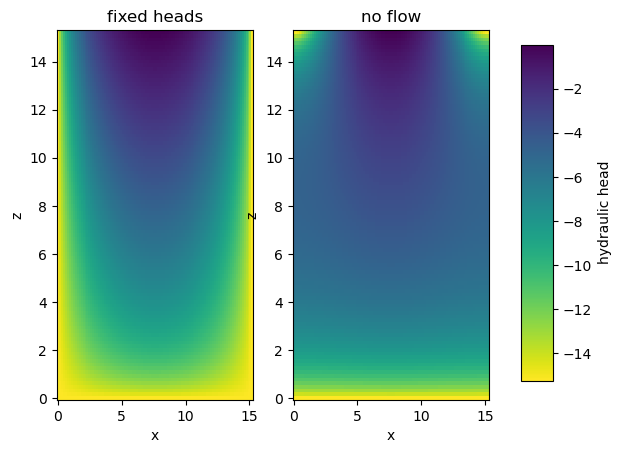

In [6]:
vmin = np.min([h_no, h_fix])
vmax = np.max([h_no, h_fix])

fig, ax = plt.subplots(1,2)
con1 = ax[0].pcolormesh(X, Z, h_fix, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0].set_title("fixed heads")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

con2 = ax[1].pcolormesh(X, Z, h_no, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1].set_title("no flow")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con2, cax=cbar_ax)
cbar.set_label("hydraulic head")



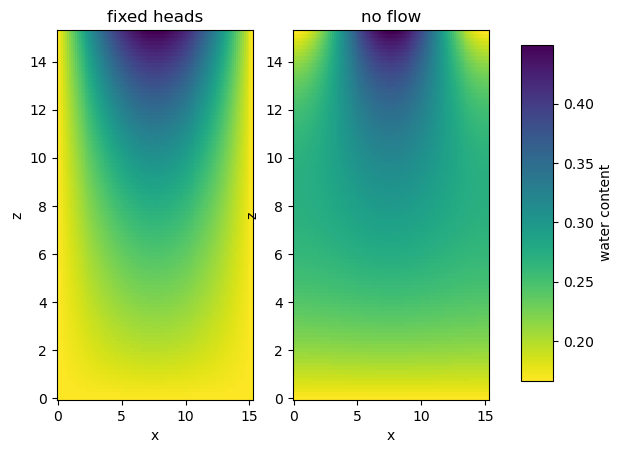

In [7]:
# plot water content
theta_fix = theta_r + (theta_s - theta_r)*np.exp(alpha*h_fix)
theta_no = theta_r + (theta_s - theta_r)*np.exp(alpha*h_no)

vmin = np.min([theta_no, theta_fix])
vmax = np.max([theta_no, theta_fix])

fig, ax = plt.subplots(1,2)
con1 = ax[0].pcolormesh(X, Z, theta_fix, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0].set_title("fixed heads")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

con2 = ax[1].pcolormesh(X, Z, theta_no, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1].set_title("no flow")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con2, cax=cbar_ax)
cbar.set_label("water content")

## Discrete solutions

In [8]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
)
from dolfinx.fem.petsc import LinearProblem, NonlinearProblem
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, create_rectangle
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    lhs,
    rhs,
    ln,
    sin,
    cos,
    pi,
)

from petsc4py import PETSc

In [9]:
# Create mesh
domain = create_rectangle(MPI.COMM_WORLD, ((0,0), (15.24, 15.24)), (100,100))
V = functionspace(domain, ("Lagrange", 1))
x = SpatialCoordinate(domain)


def van_Genuchten_kr(u):
    S = (1 + (xi * u)**n)**((1 - n) / n)
    kr = S**(0.5)*(1 - (1 - S**(n / (n - 1))) **((n - 1) / n))**2
    return kr

def Gardner_kr(u):
    return exp(alpha*u)

In [10]:
# Define Dirichlet boundary conditions

def left_or_right(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], a))

dofs_fix = locate_dofs_geometrical(
    V, lambda x: np.logical_or(left_or_right(x), np.isclose(x[1], 0)))
bc_fix = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_fix, V)

dofs_no = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 0))
bc_no = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_no, V)

def expr_h_fix(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0*np.sin(np.pi*x[0]/a))

def expr_h_noflow(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0/2*(1-np.cos(2*np.pi*x[0]/a)))


dofs_L = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], L))

h_top_fix = Function(V)
h_top_fix.interpolate(expr_h_fix)
bc_top_fix = dirichletbc(h_top_fix, dofs_L)

h_top_no = Function(V)
h_top_no.interpolate(expr_h_noflow)
bc_top_no = dirichletbc(h_top_no, dofs_L)

In [11]:
# Problem 1.

# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.minimum(x[1], 0)
    
u_k = Function(V)
u_k.interpolate(u_ini) # previous (known) solution

u_fix = TrialFunction(V)
v = TestFunction(V)

F = inner(Gardner_kr(u_k) * Ks * grad(x[1] + u_fix), grad(v)) * dx
a_fem = lhs(F)
L_fem = rhs(F)

# Picard Iteration
u_fix = Function(V) # u_{k+1} next step solution
eps = 1.0 # error measure ||u-u_k||
tol = 1e-6 # tolerance
it = 0 # iteration counter
maxiter = 75 # max number of iterations allowed

while eps > tol and it < maxiter:
    it += 1
    problem = LinearProblem(
        a_fem, L_fem, bcs=[bc_fix, bc_top_fix],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="Richards_"
    )
    u_fix = problem.solve()
    u_fix.x.array[:] = np.minimum(u_fix.x.array, 0) # make sure capillary head stays nonpositive
    diff = u_fix.x.array - u_k.x.array
    eps = np.linalg.norm(diff, ord=np.inf)
    print(f"Iteration {it}, Error ||u_k-u_(k+1)|| {eps:.3e}")
    u_k.x.array[:] = u_fix.x.array
    if eps <= tol:
        print(f"Iteration terminated due to error measure ||u_k-u_(k+1)|| = {eps:.2e} being smaller than {tol}.")
    if it >= maxiter:
        print(f"Iteration terminated due to maximum number of iterations reached.")


Iteration 1, Error ||u_k-u_(k+1)|| 1.524e+01
Iteration 2, Error ||u_k-u_(k+1)|| 7.111e+00
Iteration 3, Error ||u_k-u_(k+1)|| 4.236e+00
Iteration 4, Error ||u_k-u_(k+1)|| 2.374e+00
Iteration 5, Error ||u_k-u_(k+1)|| 2.361e+00
Iteration 6, Error ||u_k-u_(k+1)|| 1.291e+00
Iteration 7, Error ||u_k-u_(k+1)|| 1.259e+00
Iteration 8, Error ||u_k-u_(k+1)|| 6.454e-01
Iteration 9, Error ||u_k-u_(k+1)|| 6.620e-01
Iteration 10, Error ||u_k-u_(k+1)|| 3.406e-01
Iteration 11, Error ||u_k-u_(k+1)|| 3.468e-01
Iteration 12, Error ||u_k-u_(k+1)|| 1.759e-01
Iteration 13, Error ||u_k-u_(k+1)|| 1.809e-01
Iteration 14, Error ||u_k-u_(k+1)|| 9.200e-02
Iteration 15, Error ||u_k-u_(k+1)|| 9.435e-02
Iteration 16, Error ||u_k-u_(k+1)|| 4.784e-02
Iteration 17, Error ||u_k-u_(k+1)|| 4.915e-02
Iteration 18, Error ||u_k-u_(k+1)|| 2.496e-02
Iteration 19, Error ||u_k-u_(k+1)|| 2.561e-02
Iteration 20, Error ||u_k-u_(k+1)|| 1.300e-02
Iteration 21, Error ||u_k-u_(k+1)|| 1.334e-02
Iteration 22, Error ||u_k-u_(k+1)|| 6.779e-

2026-03-13 15:42:30.253 (   2.815s) [    7457CFA6E600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


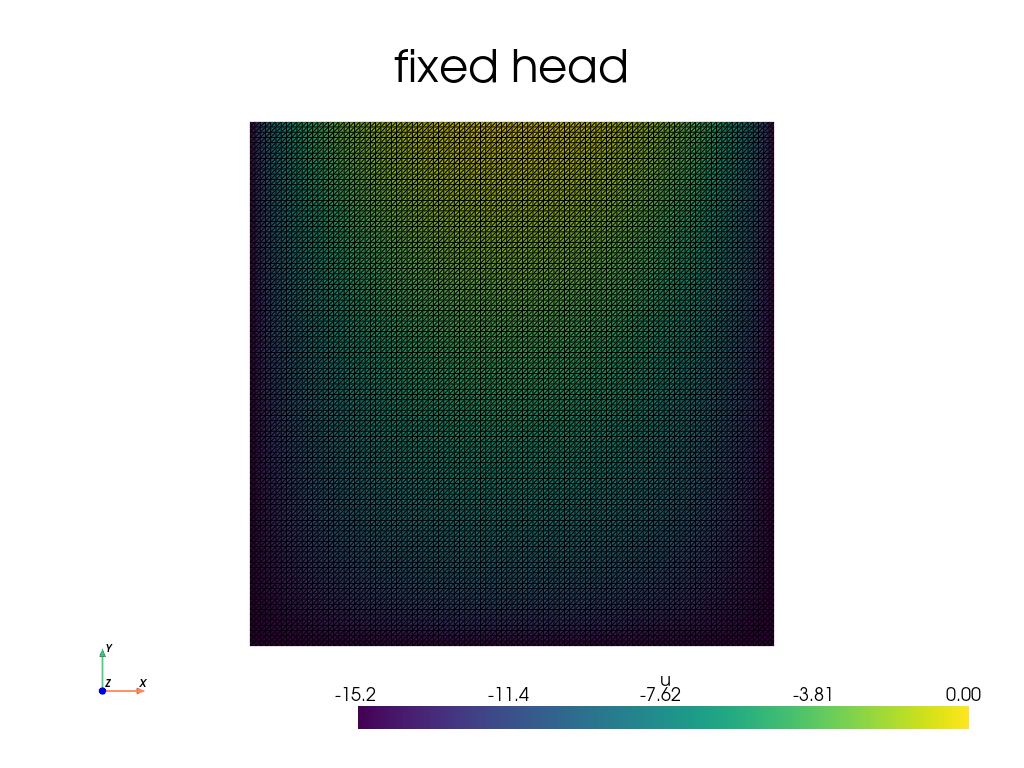

In [12]:
plotScalarFunction(V, u_fix, title="fixed head")

In [13]:
# Problem 2.

# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.minimum(x[1], 0)
    
u_k = Function(V)
u_k.interpolate(u_ini) # previous (known) solution

u_no = TrialFunction(V)
v = TestFunction(V)

F = inner(Gardner_kr(u_k) * Ks * grad(x[1] + u_no), grad(v)) * dx
a_fem = lhs(F)
L_fem = rhs(F)

# Picard Iteration
u_no = Function(V) # u_{k+1} next step solution
eps = 1.0 # error measure ||u-u_k||
tol = 1e-6 # tolerance
it = 0 # iteration counter
maxiter = 75 # max number of iterations allowed

while eps > tol and it < maxiter:
    it += 1
    problem = LinearProblem(
        a_fem, L_fem, bcs=[bc_no, bc_top_no],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="Richards_"
    )
    u_no = problem.solve()
    u_no.x.array[:] = np.minimum(u_no.x.array, 0) # make sure capillary head stays nonpositive
    diff = u_no.x.array - u_k.x.array
    eps = np.linalg.norm(diff, ord=np.inf)
    print(f"Iteration {it}, Error ||u_k-u_(k+1)|| {eps:.3e}")
    u_k.x.array[:] = u_no.x.array
    if eps <= tol:
        print(f"Iteration terminated due to error measure ||u_k-u_(k+1)|| = {eps:.2e} being smaller than {tol}.")
    if it >= maxiter:
        print(f"Iteration terminated due to maximum number of iterations reached.")


Iteration 1, Error ||u_k-u_(k+1)|| 1.524e+01
Iteration 2, Error ||u_k-u_(k+1)|| 7.413e+00
Iteration 3, Error ||u_k-u_(k+1)|| 4.484e+00
Iteration 4, Error ||u_k-u_(k+1)|| 3.470e+00
Iteration 5, Error ||u_k-u_(k+1)|| 2.949e+00
Iteration 6, Error ||u_k-u_(k+1)|| 2.532e+00
Iteration 7, Error ||u_k-u_(k+1)|| 2.009e+00
Iteration 8, Error ||u_k-u_(k+1)|| 1.646e+00
Iteration 9, Error ||u_k-u_(k+1)|| 1.377e+00
Iteration 10, Error ||u_k-u_(k+1)|| 1.173e+00
Iteration 11, Error ||u_k-u_(k+1)|| 9.505e-01
Iteration 12, Error ||u_k-u_(k+1)|| 7.907e-01
Iteration 13, Error ||u_k-u_(k+1)|| 6.554e-01
Iteration 14, Error ||u_k-u_(k+1)|| 5.556e-01
Iteration 15, Error ||u_k-u_(k+1)|| 4.530e-01
Iteration 16, Error ||u_k-u_(k+1)|| 3.798e-01
Iteration 17, Error ||u_k-u_(k+1)|| 3.128e-01
Iteration 18, Error ||u_k-u_(k+1)|| 2.648e-01
Iteration 19, Error ||u_k-u_(k+1)|| 2.162e-01
Iteration 20, Error ||u_k-u_(k+1)|| 1.822e-01
Iteration 21, Error ||u_k-u_(k+1)|| 1.493e-01
Iteration 22, Error ||u_k-u_(k+1)|| 1.265e-

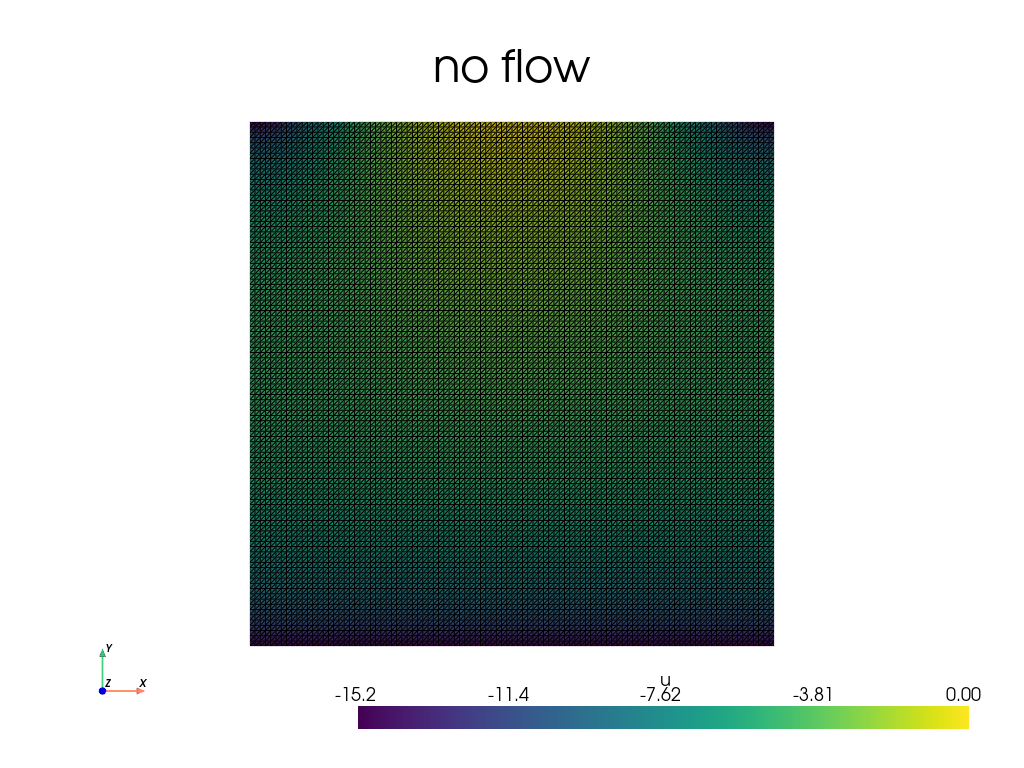

In [14]:
plotScalarFunction(V, u_no, title="no flow")

## Comparing the solutions

In [25]:
# Grids
x = np.linspace(0, a, 100)
z = np.linspace(0, L, 100)
X, Z = np.meshgrid(x, z)

In [24]:
def eval_try(x, z, u):
    h = np.zeros((len(z), len(x)))
    for i, z_cor in enumerate(z):
        p = np.vstack([x, np.full(len(x), z_cor), np.zeros(len(x))])
        pts, values = evaluate_fct(domain, p, u)
        h[i, :] = np.array(values).flatten()
    return h

heads_fix = eval_try(x, z, [u_fix])
heads_no = eval_try(x, z, [u_no])

<bound method Figure.set_tight_layout of <Figure size 640x480 with 5 Axes>>

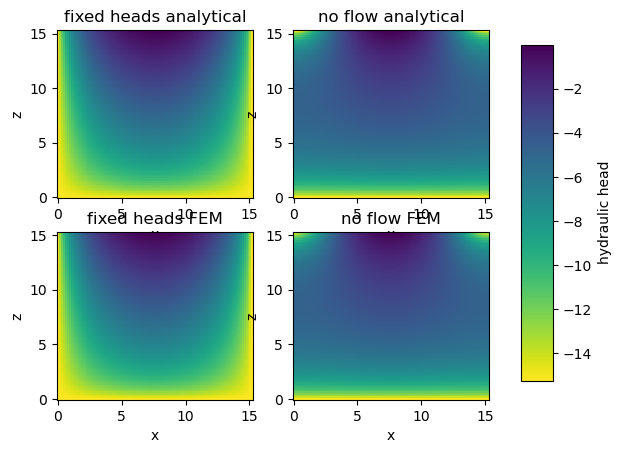

In [26]:
vmin = np.min([h_no, h_fix, heads_fix, heads_no])
vmax = np.max([h_no, h_fix, heads_fix, heads_no])

fig, ax = plt.subplots(2,2)
con1 = ax[0,0].pcolormesh(X, Z, h_fix, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0,0].set_title("fixed heads analytical")
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("z")

con2 = ax[0,1].pcolormesh(X, Z, h_no, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0,1].set_title("no flow analytical")
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("z")

con3 = ax[1,0].pcolormesh(X, Z, heads_fix, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1,0].set_title("fixed heads FEM")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("z")

con4 = ax[1,1].pcolormesh(X, Z, heads_no, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1,1].set_title("no flow FEM")
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("z")


fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con2, cax=cbar_ax)
cbar.set_label("hydraulic head")

fig.set_tight_layout